In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])


In [3]:
df.head()


,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [4]:
df.isnull().mean() * 100


Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [5]:

X = df.drop(columns=['Survived'])
y = df['Survived']

In [6]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)


In [7]:
X_train


,Age,Fare
30,40.0,27.7208
10,4.0,16.7000
873,47.0,9.0000
182,9.0,31.3875
876,20.0,9.8458
...,...,...
534,30.0,8.6625
584,NaN,8.7125
493,71.0,49.5042
527,NaN,221.7792


In [8]:

X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [9]:
X_test.tail()


,Age,Fare,Age_imputed
89,24.0,8.0500,24.0
80,22.0,9.0000,22.0
846,NaN,69.5500,NaN
870,26.0,7.8958,26.0
251,29.0,10.4625,29.0


In [10]:
X_train.loc[
    X_train['Age_imputed'].isnull(),
    'Age_imputed'
] = X_train['Age'].dropna().sample(
    X_train['Age_imputed'].isnull().sum(),
    replace=True,
    random_state=42
).values

X_test.loc[
    X_test['Age_imputed'].isnull(),
    'Age_imputed'
] = X_train['Age'].dropna().sample(
    X_test['Age_imputed'].isnull().sum(),
    replace=True,
    random_state=42
).values

In [11]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values


array([16. , 33. , 33. , 18. , 36. , 42. , 54. , 30. , 23. , 36. , 27. ,
       19. , 29. , 39. , 20. , 19. ,  2. ,  1. , 36. , 26. , 51. , 50. ,
       17. , 48. , 27. , 16. , 34.5, 44. , 36. , 58. , 47. , 24. , 33. ,
        5. , 22. , 40. , 38. , 48. , 24. ,  6. , 33. , 39. , 32. , 27. ,
       58. , 52. , 14. ,  9. , 44. , 27. , 58. , 23. , 32. , 24. , 49. ,
       11. , 21. , 28. , 24. , 17. , 18. , 31. , 30. , 29. , 25. ,  8. ,
       21. , 18. , 43. , 25. , 24. , 47. , 42. , 19. , 42. ,  1. , 26. ,
       45. , 33. , 15. , 26. , 24. , 49. , 31. , 54. , 40. , 45. , 29. ,
        9. , 31. , 31. , 30.5, 25. , 19. , 16. , 22. , 16. , 62. , 13. ,
       33. , 28. , 65. , 21. , 32. , 11. , 50. , 22. , 25. , 35. , 41. ,
       18. , 18. , 47. , 21. , 52. , 50. , 36. , 29. , 39. , 33. , 35. ,
       38. , 30. , 22. , 29. , 30. , 30. , 21. , 30. , 29. , 18. , 29. ,
        4. , 28. , 33. , 28. , 25. ,  7. , 16. , 42. , 52. , 45.5, 51. ,
       27. , 17. , 35. , 71. , 30. ])

In [12]:
X_train['Age'].isnull().sum()


np.int64(148)

In [13]:
X_train


,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,21.0
493,71.0,49.5042,71.0
527,NaN,221.7792,14.0


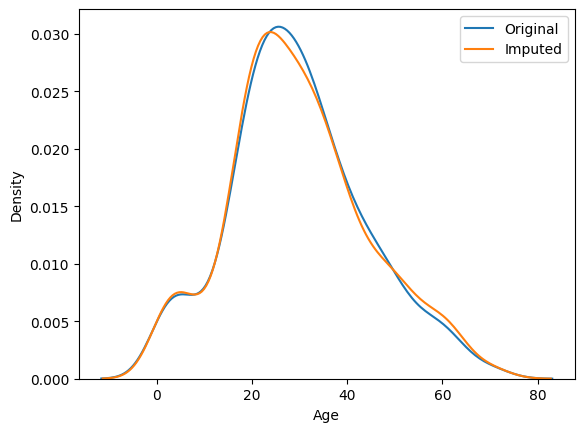

In [14]:
sns.kdeplot(X_train['Age'], label='Original')
sns.kdeplot(X_train['Age_imputed'], label='Imputed')

plt.legend()
plt.show()

In [15]:
print('Original variable variance: ', X_train['Age'].var())
print('Variance after random imputation: ', X_train['Age_imputed'].var())

Original variable variance:  204.34951339046142
Variance after random imputation:  213.4914319276537


In [16]:
X_train[['Fare', 'Age', 'Age_imputed']].cov()


,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,47.898304
Age,71.512440,204.349513,204.349513
Age_imputed,47.898304,204.349513,213.491432


<Axes: >

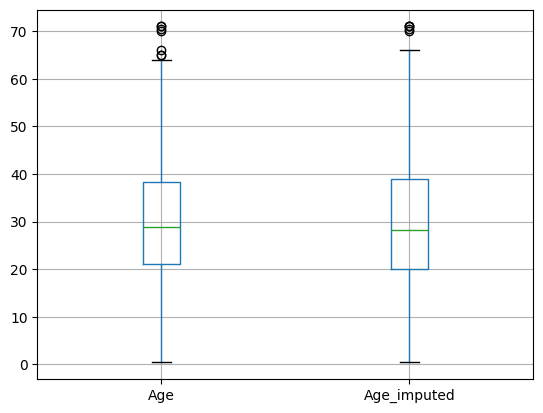

In [17]:
X_train[['Age', 'Age_imputed']].boxplot()


In [18]:
sampled_value = X_train['Age'].dropna().sample(1)

print(sampled_value)

443    28.0
Name: Age, dtype: float64


In [19]:
data = pd.read_csv('house-train.csv',usecols=['GarageQual','FireplaceQu', 'SalePrice'])


In [20]:
data.head()


,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [21]:
data.isnull().mean() * 100


FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [22]:
X = data
y = data['SalePrice']

In [23]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)


In [24]:
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

In [25]:
X_train.sample(5)


,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
1067,NaN,TA,167900,TA,NaN
83,NaN,TA,126500,TA,NaN
261,Gd,TA,276000,TA,Gd
41,Gd,TA,170000,TA,Gd
879,NaN,TA,136500,TA,NaN


In [26]:
# GarageQual imputation
X_train.loc[
    X_train['GarageQual_imputed'].isnull(),
    'GarageQual_imputed'
] = X_train['GarageQual'].dropna().sample(
    X_train['GarageQual_imputed'].isnull().sum(),
    replace=True
).values

X_test.loc[
    X_test['GarageQual_imputed'].isnull(),
    'GarageQual_imputed'
] = X_train['GarageQual'].dropna().sample(
    X_test['GarageQual_imputed'].isnull().sum(),
    replace=True
).values


# FireplaceQu imputation
X_train.loc[
    X_train['FireplaceQu_imputed'].isnull(),
    'FireplaceQu_imputed'
] = X_train['FireplaceQu'].dropna().sample(
    X_train['FireplaceQu_imputed'].isnull().sum(),
    replace=True
).values

X_test.loc[
    X_test['FireplaceQu_imputed'].isnull(),
    'FireplaceQu_imputed'
] = X_train['FireplaceQu'].dropna().sample(
    X_test['FireplaceQu_imputed'].isnull().sum(),
    replace=True
).values

In [27]:
temp = pd.concat(
        [
            X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
            X_train['GarageQual_imputed'].value_counts() / len(X_train)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

In [28]:
temp


,original,imputed
TA,0.951043,0.949486
Fa,0.037171,0.038527
Gd,0.009973,0.010274
Po,0.000907,0.000856
Ex,0.000907,0.000856


In [29]:
temp = pd.concat(
        [
            X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()),
            X_train['FireplaceQu_imputed'].value_counts() / len(df)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

temp

,original,imputed
Gd,0.494272,0.641975
TA,0.412439,0.548822
Fa,0.040917,0.046016
Po,0.027823,0.041526
Ex,0.024550,0.032548


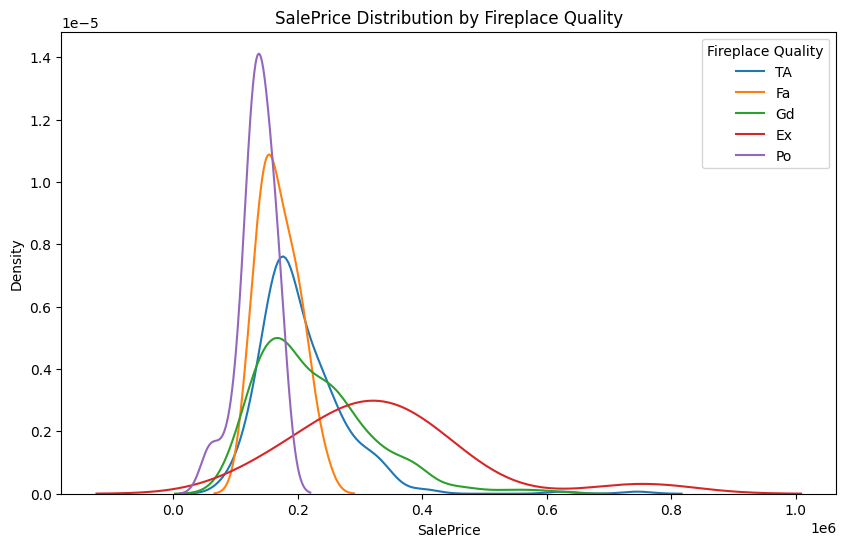

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

for category in X_train['FireplaceQu'].dropna().unique():
    sns.kdeplot(
        data=X_train[X_train['FireplaceQu'] == category],
        x='SalePrice',
        label=category,
        fill=False
    )

plt.legend(title='Fireplace Quality')
plt.xlabel('SalePrice')
plt.ylabel('Density')
plt.title('SalePrice Distribution by Fireplace Quality')

plt.show()

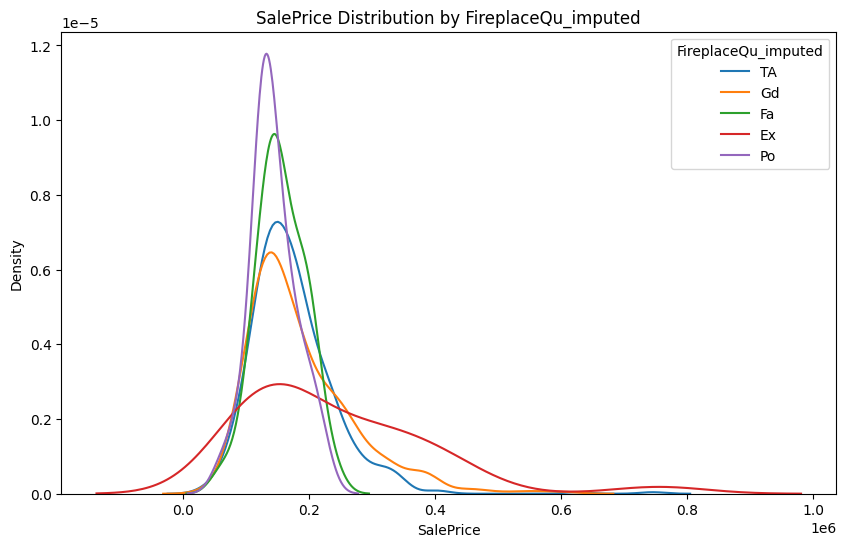

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

for category in X_train['FireplaceQu_imputed'].dropna().unique():
    sns.kdeplot(
        data=X_train[X_train['FireplaceQu_imputed'] == category],
        x='SalePrice',
        label=category
    )

plt.legend(title='FireplaceQu_imputed')
plt.xlabel('SalePrice')
plt.ylabel('Density')
plt.title('SalePrice Distribution by FireplaceQu_imputed')

plt.show()